# Ensemble Models for NBA Game Outcome Prediction

**Model Type**: Random Forest & XGBoost

**Purpose**: Capture nonlinear interactions to predict game outcome based on quarter-by-quarter trajectories.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import log_loss, roc_auc_score, roc_curve, f1_score, confusion_matrix, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set random state for reproducibility
SEED = 42
np.random.seed(SEED)

## 1. Load Data and Extract Target / Features
We create the `game_map` by looking at the `MATCHUP` column and matching team abbreviations to team IDs. Then we extract quarter-by-quarter points and differenced running stats.

In [15]:
# 1. Load Data
print('Loading data...')
df_plays = pd.read_csv('playbyplaydataraw.csv')
game_id_df = pd.read_csv('game_id.csv')

# 2. Build game_map
team_map = game_id_df.drop_duplicates('TEAM_ID').set_index('TEAM_ABBREVIATION')['TEAM_ID'].to_dict()
def get_home_away(row):
    if ' @ ' in row['MATCHUP']:
        away, home = row['MATCHUP'].split(' @ ')
    else:
        home, away = row['MATCHUP'].split(' vs. ')
    return pd.Series({
        'home_team_id': team_map.get(home),
        'away_team_id': team_map.get(away)
    })
game_map = game_id_df.apply(get_home_away, axis=1)
game_map['gameId'] = game_id_df['GAME_ID']
game_map['SEASON'] = game_id_df['SEASON']
game_map['GAME_DATE'] = game_id_df['GAME_DATE']
game_map = game_map.drop_duplicates('gameId')

print(f'Games in game_map: {len(game_map)}')


Loading data...
Games in game_map: 3690


In [16]:
# 3. Remove OT games
ot_games = df_plays[df_plays['period'] > 4]['gameId'].unique()
df_clean = df_plays[~df_plays['gameId'].isin(ot_games)].copy()
print(f'Games after OT removal: {df_clean["gameId"].nunique()}')


Games after OT removal: 3279


In [17]:
def get_quarter_scores(df_clean: pd.DataFrame, game_map: pd.DataFrame) -> pd.DataFrame:
    # End-of-period rows for regulation quarters
    df_ends = df_clean[df_clean['period'].between(1, 4) & (df_clean['subType'] == 'end')].copy()

    # One row per game/period: last end marker
    q_end = (
        df_ends.sort_values(['gameId', 'period', 'actionNumber'])
               .groupby(['gameId', 'period'])[['scoreHome', 'scoreAway']]
               .last()
               .reset_index()
    )

    # Cumulative scores at end of each quarter
    home_cum = q_end.pivot(index='gameId', columns='period', values='scoreHome')
    away_cum = q_end.pivot(index='gameId', columns='period', values='scoreAway')

    # Per-quarter points
    home_q = home_cum.diff(axis=1)
    away_q = away_cum.diff(axis=1)
    home_q[1] = home_cum[1]
    away_q[1] = away_cum[1]

    home_q.columns = ['Q1_pts', 'Q2_pts', 'Q3_pts', 'Q4_pts']
    away_q.columns = ['Q1_pts', 'Q2_pts', 'Q3_pts', 'Q4_pts']

    # Attach team IDs
    home_df = (
        home_q.reset_index()
              .merge(game_map[['gameId', 'home_team_id']], on='gameId')
              .rename(columns={'home_team_id': 'teamId'})
              .assign(is_home=1)
    )

    away_df = (
        away_q.reset_index()
              .merge(game_map[['gameId', 'away_team_id']], on='gameId')
              .rename(columns={'away_team_id': 'teamId'})
              .assign(is_home=0)
    )

    df_preprocessed = pd.concat([home_df, away_df], ignore_index=True)

    # Final points + win label
    df_preprocessed['final_pts'] = df_preprocessed[['Q1_pts', 'Q2_pts', 'Q3_pts', 'Q4_pts']].sum(axis=1)
    df_preprocessed['win'] = df_preprocessed.groupby('gameId')['final_pts'].transform(lambda x: x == x.max()).astype(int)

    return df_preprocessed


In [18]:
print('Extracting quarter scores...')
df_preprocessed = get_quarter_scores(df_clean, game_map)

# Differentials
df_opp = df_preprocessed.copy().rename(columns={
    'teamId':'opp_teamId',
    'is_home':'is_home_opp',
    'Q1_pts':'opp_Q1_pts',
    'Q2_pts':'opp_Q2_pts',
    'Q3_pts':'opp_Q3_pts',
    'Q4_pts':'opp_Q4_pts',
    'final_pts':'opp_final_pts',
    'win':'opp_win'
})

df_full = df_preprocessed.merge(df_opp, on='gameId')
df_full = df_full[df_full['teamId'] != df_full['opp_teamId']].copy()

for q in ['Q1','Q2','Q3','Q4']:
    df_full[f'{q}_diff'] = df_full[f'{q}_pts'] - df_full[f'opp_{q}_pts']

df_full['cum_diff_Q1'] = df_full['Q1_diff']
df_full['cum_diff_Q2'] = df_full['Q1_diff'] + df_full['Q2_diff']
df_full['cum_diff_Q3'] = df_full['cum_diff_Q2'] + df_full['Q3_diff']
df_full['final_diff'] = df_full['final_pts'] - df_full['opp_final_pts']  # For MAE

# Merge Season and Date
df_full = df_full.merge(game_map[['gameId', 'SEASON', 'GAME_DATE']], on='gameId', how='left')
df_full = df_full.sort_values('GAME_DATE').reset_index(drop=True)
print(f'Processed dataset size: {df_full.shape}')


Extracting quarter scores...
Processed dataset size: (6558, 27)


## 2. Train / Val / Test Split
Chronological split as per requirement:
- Train: 2022-23 and 2023-24 seasons
- Validation/Test: 50/50 sequential split of the 2024-25 season.

In [19]:
train_df = df_full[df_full['SEASON'].isin(['2022-23', '2023-24'])].copy()
split_2425 = df_full[df_full['SEASON'] == '2024-25'].copy()
split_2425 = split_2425.sort_values('GAME_DATE').reset_index(drop=True)

# Split on gameId to ensure both teams maps to same split
unique_2425_games = pd.Series(split_2425['gameId'].unique())
mid = len(unique_2425_games) // 2
val_games = unique_2425_games[:mid]
test_games = unique_2425_games[mid:]

val_df = split_2425[split_2425['gameId'].isin(val_games)].copy()
test_df = split_2425[split_2425['gameId'].isin(test_games)].copy()

print(f'Train set: {train_df["gameId"].nunique()} games')
print(f'Validation set: {val_df["gameId"].nunique()} games')
print(f'Test set: {test_df["gameId"].nunique()} games')


Train set: 2236 games
Validation set: 521 games
Test set: 522 games


## 3. Ensemble Model Configuration & Training
We configure a Classifier (to predict WIN/LOSS) and a Regressor (to predict Point-Spread `final_diff`). We utilize both Random Forest and XGBoost classifiers.

In [20]:
# Define features and targets
FEATURES = ['is_home', 'Q1_pts', 'Q2_pts', 'Q3_pts', 'opp_Q1_pts', 'opp_Q2_pts', 'opp_Q3_pts', 
            'Q1_diff', 'Q2_diff', 'Q3_diff', 'cum_diff_Q1', 'cum_diff_Q2', 'cum_diff_Q3']
TARGET_CLASS = 'win'
TARGET_REG = 'final_diff'

X_train, y_train_cls, y_train_reg = train_df[FEATURES], train_df[TARGET_CLASS], train_df[TARGET_REG]
X_val, y_val_cls, y_val_reg = val_df[FEATURES], val_df[TARGET_CLASS], val_df[TARGET_REG]
X_test, y_test_cls, y_test_reg = test_df[FEATURES], test_df[TARGET_CLASS], test_df[TARGET_REG]

print(f'Using {len(FEATURES)} features.')


Using 13 features.


In [21]:
# Initialize models
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED)
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=SEED)

xgb_clf = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=SEED)
xgb_reg = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=SEED)

# Train Classifiers
print('Training Classifiers (Win Predictor)...')
rf_clf.fit(X_train, y_train_cls)
xgb_clf.fit(X_train, y_train_cls)

# Train Regressors
print('Training Regressors (Point Spread Estimator)...')
rf_reg.fit(X_train, y_train_reg)
xgb_reg.fit(X_train, y_train_reg)


Training Classifiers (Win Predictor)...
Training Regressors (Point Spread Estimator)...


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

## 4. Evaluation

In [22]:
def evaluate_classifier(model, X, y_true, name):
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = model.predict(X)
    loss = log_loss(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    print(f'--- {name} Classification Performance ---')
    print(f'Log-Loss: {loss:.4f}')
    print(f'F1-Score: {f1:.4f}')
    print(f'ROC AUC : {auc:.4f}')
    print('Confusion Matrix:')
    print(cm)
    print()
    return y_prob, y_pred

def evaluate_regressor(model, X, y_true, name):
    y_pred = model.predict(X)
    mae = mean_absolute_error(y_true, y_pred)
    print(f'--- {name} Regression Performance ---')
    print(f'MAE (Point-Spread Error): {mae:.4f}')
    print()
    return y_pred

# Evaluation on Test Set
print('==================== TEST SET ======================')
rf_prob_test, _ = evaluate_classifier(rf_clf, X_test, y_test_cls, 'Random Forest')
xgb_prob_test, _ = evaluate_classifier(xgb_clf, X_test, y_test_cls, 'XGBoost')

rf_pred_spread = evaluate_regressor(rf_reg, X_test, y_test_reg, 'Random Forest')
xgb_pred_spread = evaluate_regressor(xgb_reg, X_test, y_test_reg, 'XGBoost')


==================== TEST SET ======================
--- Random Forest Classification Performance ---
Log-Loss: 0.3369
F1-Score: 0.8654
ROC AUC : 0.9336
Confusion Matrix:
[[454  68]
 [ 72 450]]

--- XGBoost Classification Performance ---
Log-Loss: 0.3242
F1-Score: 0.8670
ROC AUC : 0.9366
Confusion Matrix:
[[452  70]
 [ 69 453]]

--- Random Forest Regression Performance ---
MAE (Point-Spread Error): 6.6614

--- XGBoost Regression Performance ---
MAE (Point-Spread Error): 6.6435



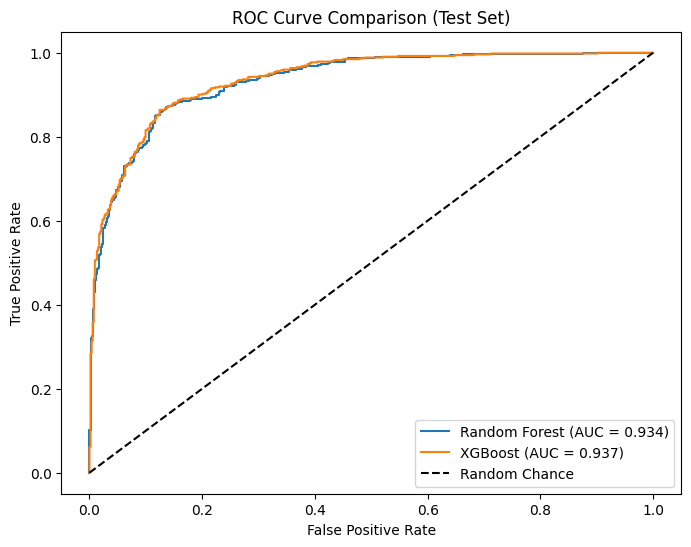

In [23]:
# ROC Curve Plot on Test Set
fpr_rf, tpr_rf, _ = roc_curve(y_test_cls, rf_prob_test)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_cls, xgb_prob_test)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test_cls, rf_prob_test):.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test_cls, xgb_prob_test):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Test Set)')
plt.legend(loc='lower right')
plt.show()


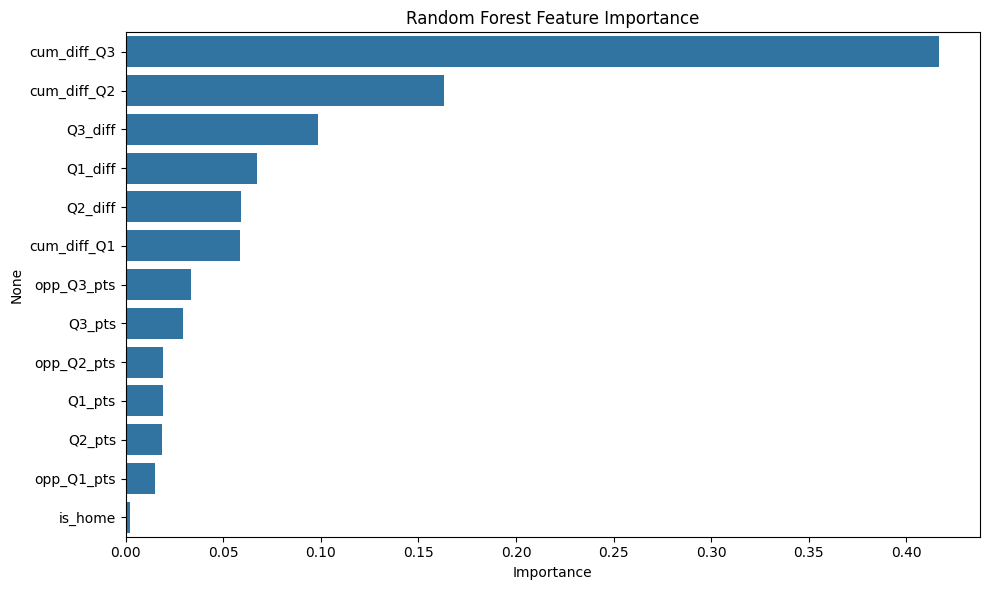

In [ ]:
# Feature Importances (RandomForest)
feature_importances = pd.Series(rf_clf.feature_importances_, index=FEATURES).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

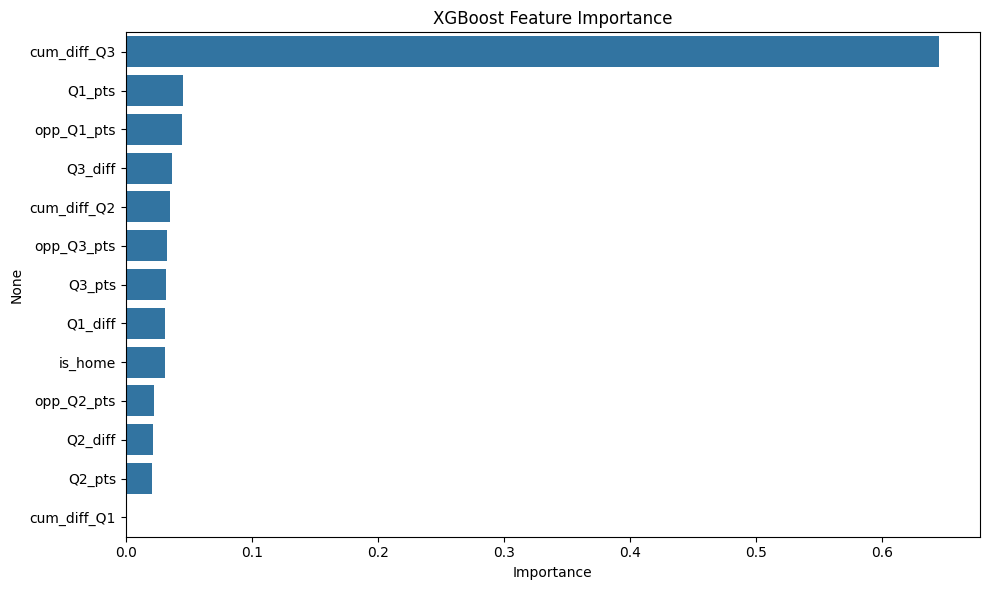

In [24]:
# Feature Importances (XGBoost)
feature_importances = pd.Series(xgb_clf.feature_importances_, index=FEATURES).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
